# Model Building and Evaluation

## Project Objective

The objective of this notebook is to build, evaluate, compare and optmize multiple Machine Learning models for healthcare risk prediction.

The following models were explored:
- Logistic Regression
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost

Model performance was evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- ROC-AUC Curve

The project also includes Hyperparameter Tuning and Explainable AI using SHAP. 

# Import Requried libraries

In [56]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
The cleaned healthcare dataset is loaded for Machine Learning model training and evaluation

In [57]:
df = pd.read_csv("../data/novagen_dataset.csv")
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


# Feature and Target Separation

The dataset is divided into:
- Input Features (X)
- Target Variable (y)

In [58]:
X = df.drop("Target", axis=1)
y = df["Target"]
X.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [59]:
y.head()

0    1
1    1
2    0
3    0
4    0
Name: Target, dtype: int64

# Train-Test Split
The dataset is divided into training and testing sets to evaluate model performance on unseen data. 

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
# Feature Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Logistic Regression

Logistic Regression was used as the baseline classification model to establish initial predictive performance. 

In [62]:

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [63]:
y_pred = model.predict(X_test_scaled)

In [64]:
# Evaluation
print("accuracy = ", accuracy_score(y_test, y_pred))
print("classification_report: ")
print(classification_report(y_test, y_pred))

accuracy =  0.8225130890052356
classification_report: 
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       900
           1       0.83      0.84      0.83      1010

    accuracy                           0.82      1910
   macro avg       0.82      0.82      0.82      1910
weighted avg       0.82      0.82      0.82      1910



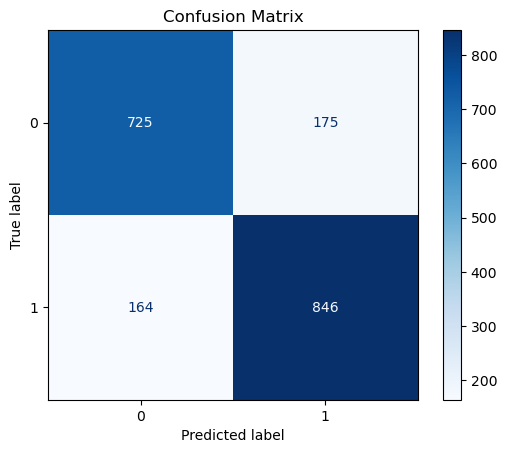

In [65]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Logistic Regression Insights
- Logistic Regression achieved solid baseline performance on the healthcare dataset.
- The model successfully captured general linear relationship between features and health outcomes.
- However, healthcare-related patterns are often nonlinear and complex, limiting the model's overall predictive capability. 


# Decision Tree Classifier

Decision Trees were explored to capture nonlinear feature interactions and hierarchical decision-making patterns. 

In [66]:
# Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth = 5,
    random_state = 42
)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [67]:
y_pred_dt = dt_model.predict(X_test)

In [68]:
print("accuracy = ", accuracy_score(y_test, y_pred_dt))
print("classification report : ")
print(classification_report(y_test, y_pred_dt))

accuracy =  0.856020942408377
classification report : 
              precision    recall  f1-score   support

           0       0.90      0.78      0.84       900
           1       0.83      0.92      0.87      1010

    accuracy                           0.86      1910
   macro avg       0.86      0.85      0.85      1910
weighted avg       0.86      0.86      0.85      1910



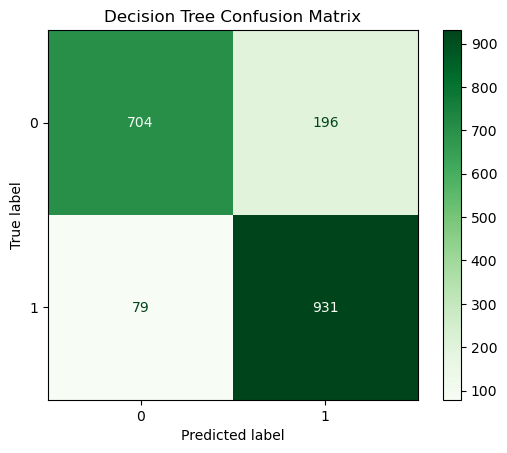

In [69]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Decision Tree Insights

- Decision Tree performance improved over Logistic Regression by capturing nonlinear relationships.
- The model achieved stronger recall and classification preformance.
- However, deeper trees showed signs of overfitting, requiring depth control for better generalization. 

In [70]:
# Test for Overfitting 
train_accuracy = dt_model.score(X_train, y_train)
test_accuracy = dt_model.score(X_test, y_test)

print("Training Accuracy: ", train_accuracy)
print("Testing Accuracy: ", test_accuracy)

Training Accuracy:  0.8590129598114936
Testing Accuracy:  0.856020942408377


# Overfitting Analysis

Training and testing accuracy were analyzed across different tree depths to study model complexity and overfitting behavior. 

In [71]:
depths = range(1, 21)

train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth = depth,
        random_state = 42
    )
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

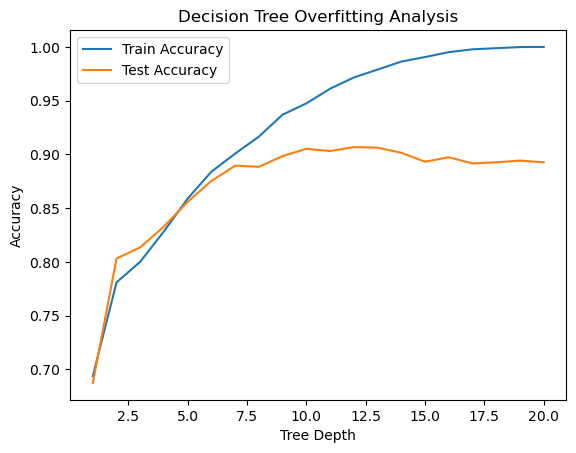

In [72]:
plt.plot(depths, train_scores, label="Train Accuracy")

plt.plot(depths, test_scores, label="Test Accuracy")

plt.xlabel("Tree Depth")

plt.ylabel("Accuracy")

plt.title("Decision Tree Overfitting Analysis")

plt.legend()

plt.show()

## Overfitting Observation
As tree depth increased, training accuracy continued improving while testing accuracy plateaued, indicating overfitting behavior in deeper Decision Trees. 

A maximum depth of 5 provided a strong balance between learning capacity and generalization.  

# Random Forest Classifier

Random Forest combines multiple Decision Trees using bagging techniques to improve robustness, reduce variance, and enhance generalization performance.

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 8,
    random_state = 42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, random_state=42)

In [74]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy:  0.912041884816754
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       900
           1       0.90      0.94      0.92      1010

    accuracy                           0.91      1910
   macro avg       0.91      0.91      0.91      1910
weighted avg       0.91      0.91      0.91      1910



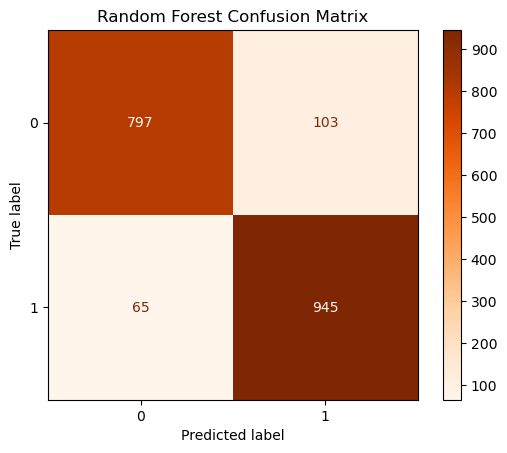

In [75]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Random Forest Insights

- Random Forest significantly improved prediction performance compared to single Decision Trees.
- Ensemble averaging reduced overfitting and improved model stability.
- The model achieved strong recall and balanced classification performance for healthcare risk prediction.

In [76]:
# Feature Importance
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importances = feature_importances.sort_values(
    by = "Importance",
    ascending = False
)
print(feature_importances)

                  Feature  Importance
1                     BMI    0.292143
2          Blood_Pressure    0.187336
3             Cholesterol    0.121107
9            Stress_Level    0.091506
4           Glucose_Level    0.067712
6             Sleep_Hours    0.060706
0                     Age    0.054119
8            Water_Intake    0.043438
5              Heart_Rate    0.042479
7          Exercise_Hours    0.015583
13           MentalHealth    0.002846
15         MedicalHistory    0.002577
10                Smoking    0.002548
16              Allergies    0.002521
12                   Diet    0.002397
11                Alcohol    0.002312
14       PhysicalActivity    0.002165
18  Diet_Type__Vegetarian    0.001676
17       Diet_Type__Vegan    0.001303
20          Blood_Group_B    0.001218
21          Blood_Group_O    0.001174
19         Blood_Group_AB    0.001135


# Feature Importance Analysis

Random Forest feature importance was analyzed to identify the most influential healthcare indicators affecting predictions.

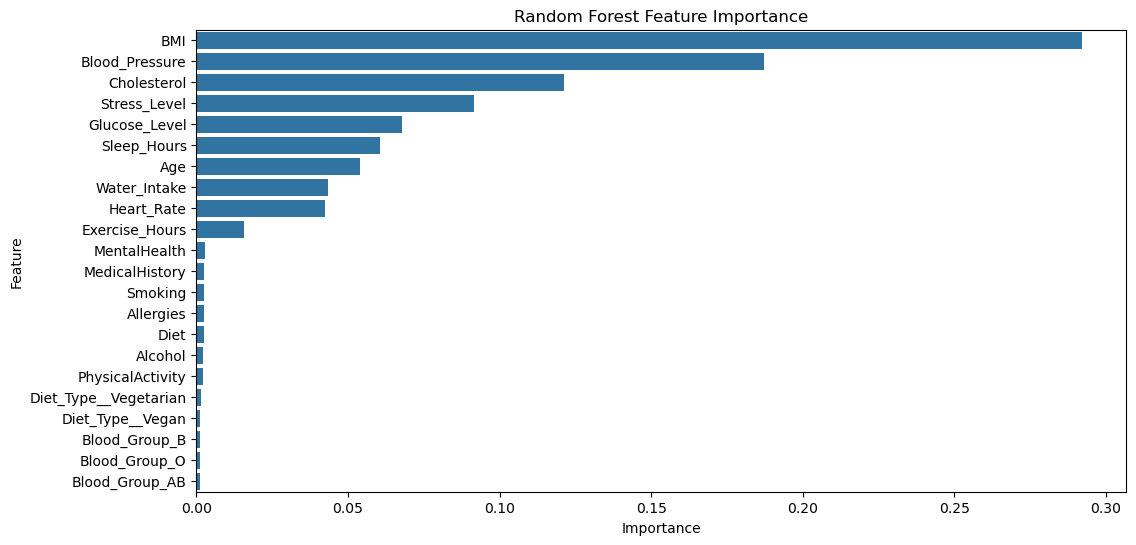

In [77]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data = feature_importances
)
plt.title("Random Forest Feature Importance")
plt.show()

## Feature Importance Insights

- BMI emerged as the most influential predictor in healthcare risk prediction.
- Blood Pressure and Cholesterol also showed strong predictive contribution.
- Stress Level demonstrated moderate importance, highlighting the role of mental and lifestyle factors.
- Several categorical lifestyle indicators contributed comparatively less to final predictions.

# Boosting Algorithms

Boosting methods were explored to improve predictive performance by sequentially correcting errors from weaker learners.

## AdaBoost

AdaBoost combines multiple weak learners sequentially, focusing more heavily on previously misclassified samples.

In [78]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators = 100,
    learning_rate = 1.0,
    random_state = 42
)
ada_model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [79]:
y_pred_ada = ada_model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred_ada))
print("Classification report: ")
print(classification_report(y_test, y_pred_ada))

Accuracy:  0.8471204188481676
Classification report: 
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       900
           1       0.85      0.86      0.86      1010

    accuracy                           0.85      1910
   macro avg       0.85      0.85      0.85      1910
weighted avg       0.85      0.85      0.85      1910



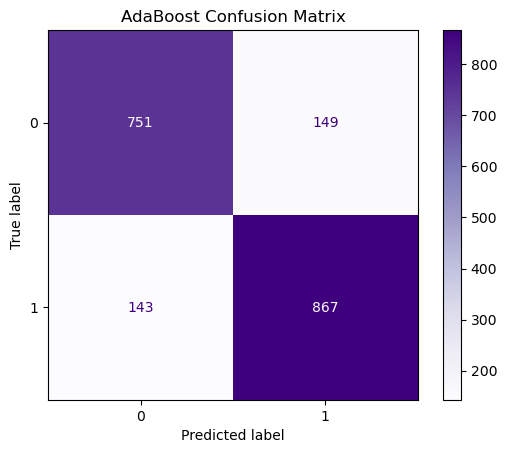

In [80]:
cm = confusion_matrix(y_test, y_pred_ada)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)

disp.plot(cmap = "Purples")
plt.title("AdaBoost Confusion Matrix")
plt.show()

### AdaBoost Insights

- AdaBoost improved overall classification capability compared to baseline models.
- However, its performance remained slightly lower than Random Forest and Gradient Boosting models.
- The model struggled to fully capture complex healthcare feature interactions.

## Gradient Boosting

Gradient Boosting incrementally minimizes prediction errors using gradient optimization techniques.

In [81]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [82]:
y_pred_gb = gb_model.predict(X_test)

print("Accuracy = ", accuracy_score(y_test, y_pred_gb))
print("Classification Report: ")
print(classification_report(y_test, y_pred_gb))

Accuracy =  0.9183246073298429
Classification Report: 
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       900
           1       0.92      0.92      0.92      1010

    accuracy                           0.92      1910
   macro avg       0.92      0.92      0.92      1910
weighted avg       0.92      0.92      0.92      1910



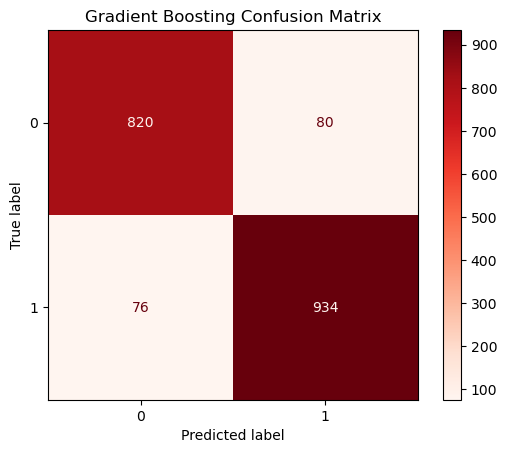

In [83]:
cm = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap ="Reds")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

### Gradient Boosting Insights

- Gradient Boosting achieved excellent predictive performance and balanced classification behavior.
- The model significantly reduced both false positives and false negatives.
- Ensemble boosting allowed the model to capture highly complex nonlinear patterns.

## XGBoost

XGBoost is an optimized gradient boosting framework designed for efficiency, regularization, and high predictive performance.

In [84]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators = 100,
    max_depth= 4,
    learning_rate = 0.1,
    random_state = 42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [85]:
y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy = ", accuracy_score(y_test, y_pred_xgb))
print("classification report: ")
print(classification_report(y_test, y_pred_xgb))

Accuracy =  0.9246073298429319
classification report: 
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       900
           1       0.93      0.93      0.93      1010

    accuracy                           0.92      1910
   macro avg       0.92      0.92      0.92      1910
weighted avg       0.92      0.92      0.92      1910



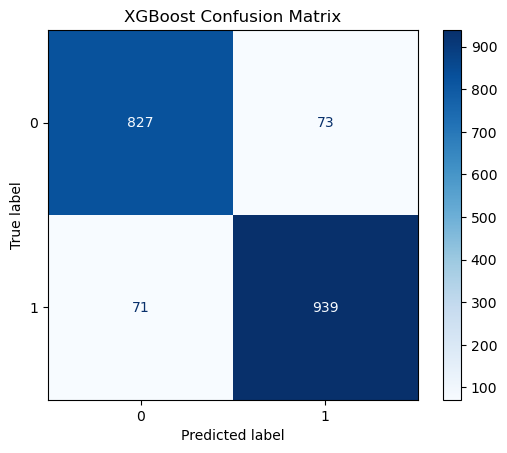

In [86]:
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = "Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

### XGBoost Insights

- XGBoost achieved the strongest overall performance among all evaluated models.
- The model demonstrated excellent balance between precision, recall, and overall accuracy.
- Regularization and boosting optimization enabled superior generalization capability.

# ROC-AUC Curve Comparison

ROC-AUC analysis was performed to evaluate the discrimination capability of ensemble models across varying classification thresholds.

In [87]:
from sklearn.metrics import roc_curve, auc

rf_probs = rf_model.predict_proba(X_test)[:,1]
gb_probs = gb_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

In [88]:
# for random forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

# for gradient boosting
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)
gb_auc = auc(gb_fpr, gb_tpr)

# for xgboost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
xgb_auc = auc(xgb_fpr, xgb_tpr)

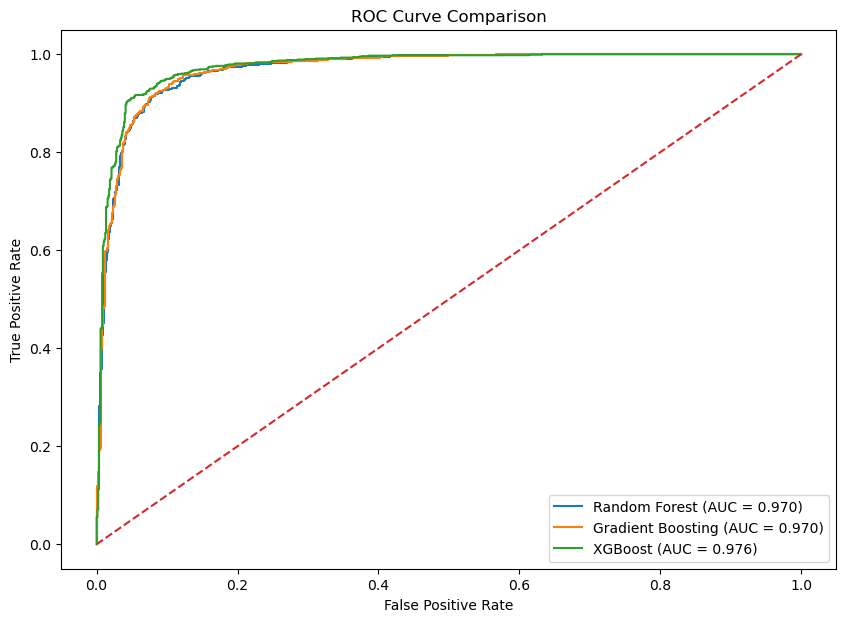

In [89]:
plt.figure(figsize=(10, 7))

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(gb_fpr, gb_tpr, label=f"Gradient Boosting (AUC = {gb_auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.3f})")

# Random Guess Line
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## ROC-AUC Insights

- All ensemble models demonstrated excellent classification capability.
- XGBoost achieved the highest ROC-AUC score among all evaluated models.
- ROC curves remaining close to the top-left corner indicated strong sensitivity and specificity.

# Hyperparameter Tuning

RandomizedSearchCV was used to identify optimal model parameters and improve model generalization performance.

In [90]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [3, 4,5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':[0.8, 1.0],
    'colsample_bytree':[0.8, 1.0]
}

xgb = XGBClassifier(
    random_state = 42,
    eval_metric = 'logloss'
)

random_search =RandomizedSearchCV(
    estimator=xgb,
    param_distributions = param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [91]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [50, 100, 200],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [92]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
0.9836086856570813


In [93]:
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred_best))
print("classification report: ")
print(classification_report(y_test, y_pred_best))

Accuracy:  0.9486910994764398
classification report: 
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       900
           1       0.95      0.95      0.95      1010

    accuracy                           0.95      1910
   macro avg       0.95      0.95      0.95      1910
weighted avg       0.95      0.95      0.95      1910



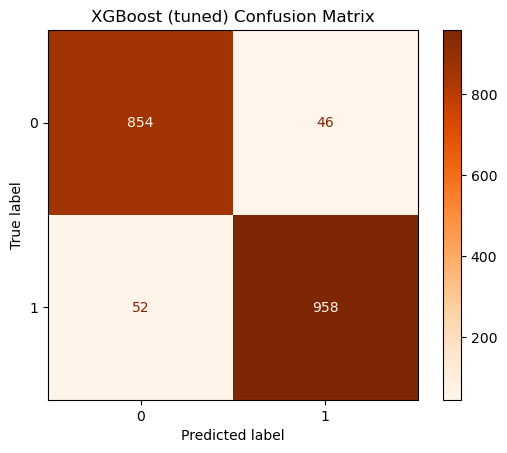

In [94]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Oranges")
plt.title("XGBoost (tuned) Confusion Matrix")
plt.show()

## Hyperparameter Tuning Insights

- Hyperparameter optimization significantly improved overall model performance.
- The tuned XGBoost model achieved better balance between bias and variance.
- Both Type I and Type II classification errors were reduced after optimization.

# Explainable AI using SHAP

SHAP (SHapley Additive exPlanations) was used to interpret model predictions and understand feature contribution behavior.

In [95]:
import shap
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

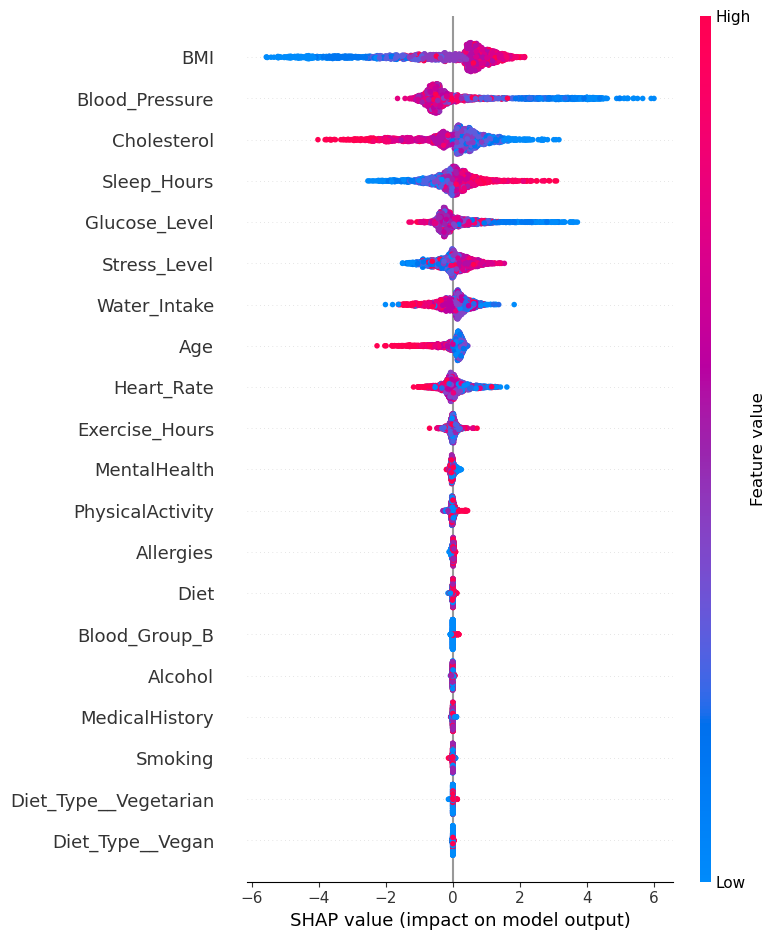

In [96]:
shap.summary_plot(shap_values, X_test)

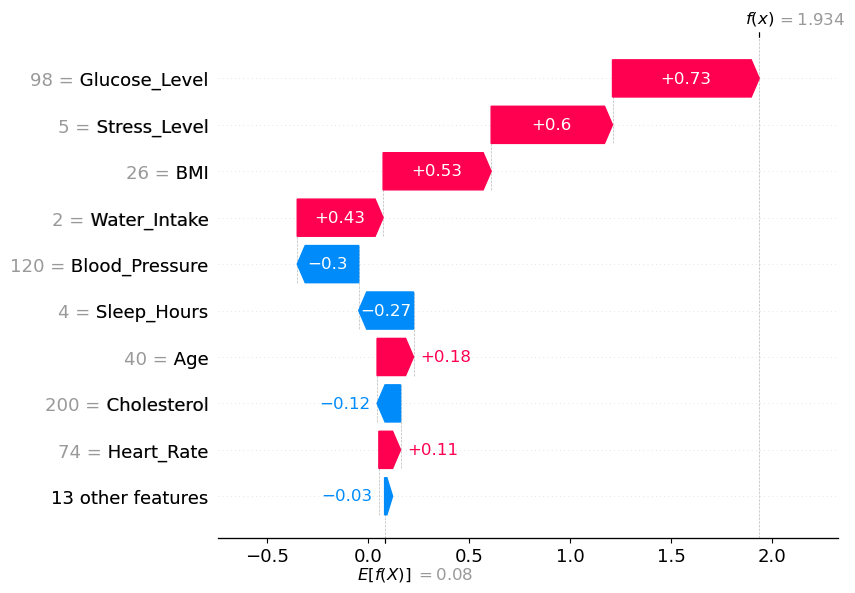

In [97]:
# Water plot
patient_index = 75

shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[patient_index],
        base_values = explainer.expected_value,
        data = X_test.iloc[patient_index],
        feature_names = X_test.columns
    )
)

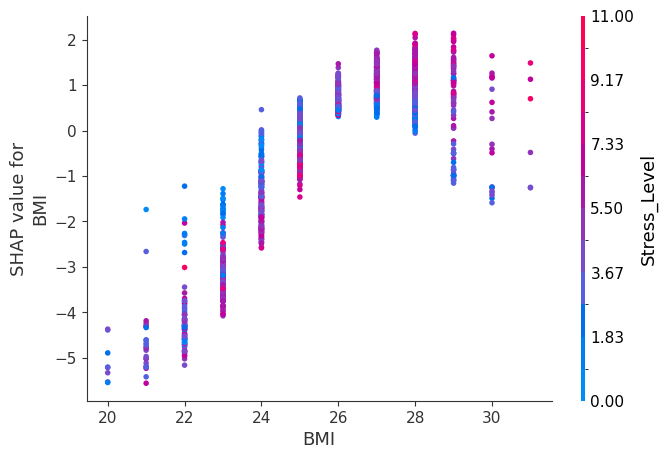

In [98]:
# Dependence Plot
shap.dependence_plot(
    "BMI",
     shap_values,
     X_test
)

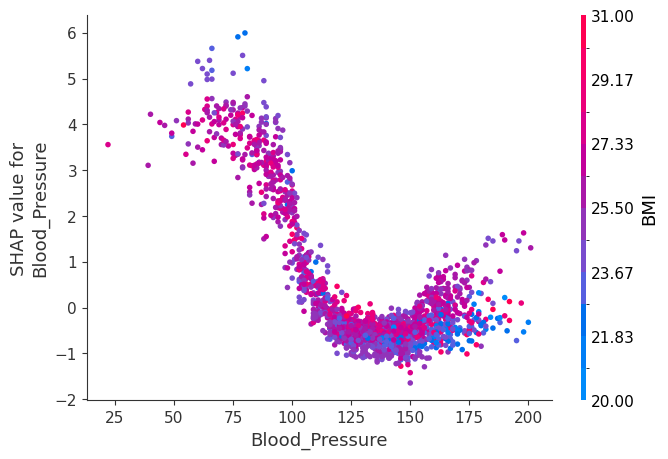

In [99]:
shap.dependence_plot(
    "Blood_Pressure",
    shap_values,
    X_test
)

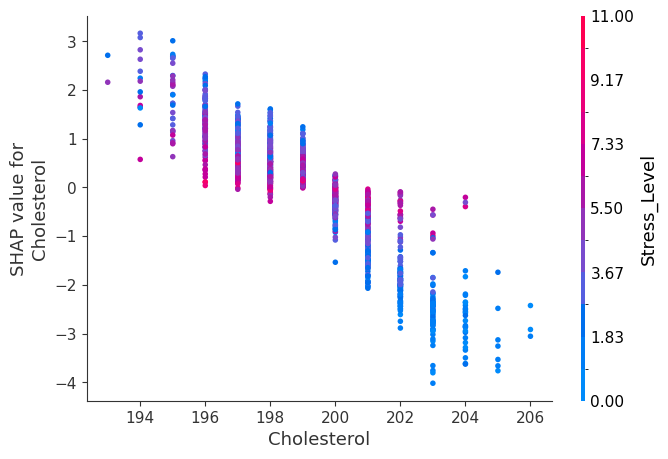

In [100]:
shap.dependence_plot(
    "Cholesterol",
    shap_values,
    X_test
)

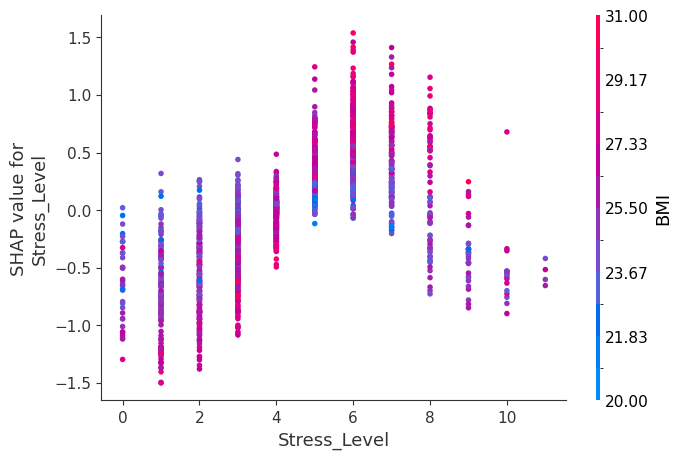

In [101]:
shap.dependence_plot(
    "Stress_Level",
    shap_values,
    X_test
)

## SHAP Insights

- BMI, Blood Pressure, and Cholesterol consistently showed the strongest influence on prediction outcomes.
- Higher BMI and Blood Pressure values contributed positively toward unhealthy risk predictions.
- SHAP analysis improved interpretability and transparency of the healthcare prediction system.

# Model Performance Comparison

A comparison table was created to evaluate the performance of all trained Machine Learning models across multiple evaluation metrics.

In [102]:
results = {
    "Model" : [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy":[
        0.8225,
        0.8560,
        0.9120,
        0.8471,
        0.9183,
        0.9246,
        0.9487
    ],
    "Recall":[
        0.84,
        0.92,
        0.94,
        0.86,
        0.92,
        0.93,
        0.95
    ],
    "Precision":[
        0.83,
        0.83,
        0.90,
        0.85,
        0.92,
        0.93,
        0.95
    ],
    "F1-Score":[
        0.83,
        0.87,
        0.92,
        0.86,
        0.92,
        0.93,
        0.95,
    ],
    "ROC-AUC":[
        None,
        None, 
        0.970,
        None, 
        0.970,
        0.976,
        0.984
    ],
    "False Negatives":[
        164,
        79,
        65,
        143,
        76,
        71,
        52
    ]
}

results_df = pd.DataFrame(results)


In [103]:
results_df.sort_values(
    by = "Accuracy",
    ascending=False
)

,Model,Accuracy,Recall,Precision,F1-Score,ROC-AUC,False Negatives
6,Tuned XGBoost,0.9487,0.95,0.95,0.95,0.984,52
5,XGBoost,0.9246,0.93,0.93,0.93,0.976,71
4,Gradient Boosting,0.9183,0.92,0.92,0.92,0.970,76
2,Random Forest,0.9120,0.94,0.90,0.92,0.970,65
1,Decision Tree,0.8560,0.92,0.83,0.87,NaN,79
3,AdaBoost,0.8471,0.86,0.85,0.86,NaN,143
0,Logistic Regression,0.8225,0.84,0.83,0.83,NaN,164


## Model Comparison Insights

- Ensemble learning models consistently outperformed baseline models.
- Random Forest, Gradient Boosting, and XGBoost achieved the strongest overall classification performance.
- XGBoost demonstrated the best balance between accuracy, precision, recall, and generalization capability.
- The comparison process helped identify the most suitable model for healthcare risk prediction.

In [104]:
# Saving the Final Model
import joblib
joblib.dump(best_xgb, "../models/health_risk_model.pkl")

['../models/health_risk_model.pkl']

In [105]:
joblib.dump(
    X.columns.tolist(),
    "../models/model_features.pkl"
)

['../models/model_features.pkl']

## Saving the Final Model

The best-performing trained model and feature configuration were saved for future inference and deployment purposes.

In [106]:
# Test loading
loaded_model = joblib.load("../models/health_risk_model.pkl")
loaded_features = joblib.load("../models/model_features.pkl")

print(loaded_features)

['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level', 'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake', 'Stress_Level', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth', 'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type__Vegan', 'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B', 'Blood_Group_O']


## Model Loading Verification

- The saved model was successfully reloaded without errors.
- Prediction consistency confirmed correct model serialization.
- This validation step ensures the model is deployment-ready for Streamlit integration and future inference tasks.

# Final Conclusion

Among all evaluated Machine Learning models, the tuned XGBoost classifier achieved the strongest overall performance.

The project successfully demonstrated:
- End-to-end Machine Learning workflow
- Ensemble learning techniques
- Hyperparameter optimization
- Model explainability using SHAP
- Streamlit deployment for interactive prediction

The final system provides an interpretable and highly accurate healthcare risk prediction solution.